<div style='font-size:14px'>now we will analyse what is the ay for each particular field in any role

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

df_DA_India = df_DA_India.dropna(subset='salary_year_avg')

In [4]:
df_DA_India = df_DA_India.explode('job_skills')

In [16]:
df_DA_India_group = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['median','count'])

df_DA_top_pay = df_DA_India_group.sort_values(by='median',ascending=False).head(10)

df_DA_top_skills = df_DA_India_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False)

df_DA_top_skills

,median,count
job_skills,,
spark,111175.0,11
power bi,111175.0,17
tableau,108087.5,20
excel,98500.0,39
sql,96050.0,46
python,96050.0,36
azure,93600.0,15
r,79200.0,18
aws,79200.0,12


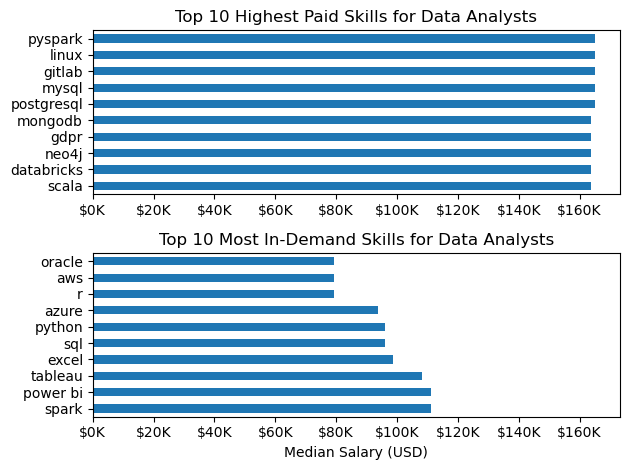

In [23]:
fig, ax= plt.subplots(2,1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
# ax[0].invert_yaxis() this is used to invert y axis but another method to invert y axis is [::-1as we will strt from bottom]
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

df_DA_top_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim()) #this will set xlim similar to ax[0]'s lim
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()